# California Housing

Carga de variables predictoras y objetivo, con 80 % para entrenamiento y 20 % para prueba.

In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split


In [2]:
housing = fetch_california_housing()
X = housing.data
y = housing.target

print(f"Data: {X.shape}")
print(f"Target: {y.shape}")


Data: (20640, 8)
Target: (20640,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")


X_train: (16512, 8)
X_test: (4128, 8)
y_train: (16512,)
y_test: (4128,)


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression()),
])


In [22]:
from sklearn.model_selection import KFold

cv = KFold(n_splits=50, shuffle=True, random_state=42)

cv


KFold(n_splits=50, random_state=42, shuffle=True)

## Validación cruzada y métrica

Usamos **RMSE** como métrica principal para este problema de regresión: conserva las unidades del objetivo y penaliza especialmente los errores grandes. `MedHouseVal` está expresado en cientos de miles de dólares; multiplicar el RMSE por 100 000 permite interpretarlo en dólares. MAE y R² se incluyen como métricas complementarias.

La validación cruzada de 5 particiones se realiza solamente sobre entrenamiento. El `Pipeline` ajusta el escalador dentro de cada partición para evitar fuga de información. Scikit-learn devuelve los errores con signo negativo; los convertimos a valores positivos. La desviación estándar resume la variabilidad entre particiones, no un intervalo de confianza. El conjunto de prueba se reserva para la evaluación final.

In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2",
    },
    error_score="raise",
)

cv_scores = pd.DataFrame({
    "RMSE": -cv_results["test_rmse"],
    "MAE": -cv_results["test_mae"],
    "R²": cv_results["test_r2"],
}, index=pd.Index(range(1, cv.n_splits + 1), name="Partición"))
cv_summary = cv_scores.agg(["mean", "std"]).rename(
    index={"mean": "Media", "std": "Desviación estándar"}
)

display(cv_scores.round(4))
display(cv_summary.round(4))
print(
    f"RMSE CV: {cv_scores['RMSE'].mean():.4f} "
    f"± {cv_scores['RMSE'].std():.4f} (media ± desviación estándar)"
)
print(f"RMSE medio equivalente: ${cv_scores['RMSE'].mean() * 100_000:,.0f}")

,RMSE,MAE,R²
Partición,,,
1,0.8108,0.5809,0.5472
2,0.6960,0.5184,0.6464
3,0.7011,0.5131,0.6314
4,0.7711,0.5758,0.5987
5,0.7351,0.5486,0.6051
6,0.6992,0.5249,0.6593
7,0.7467,0.5307,0.5672
8,0.7108,0.5227,0.6300
9,0.7166,0.5377,0.5970


,RMSE,MAE,R²
Media,0.7193,0.5291,0.6103
Desviación estándar,0.0485,0.0313,0.0400


RMSE CV: 0.7193 ± 0.0485 (media ± desviación estándar)
RMSE medio equivalente: $71,926


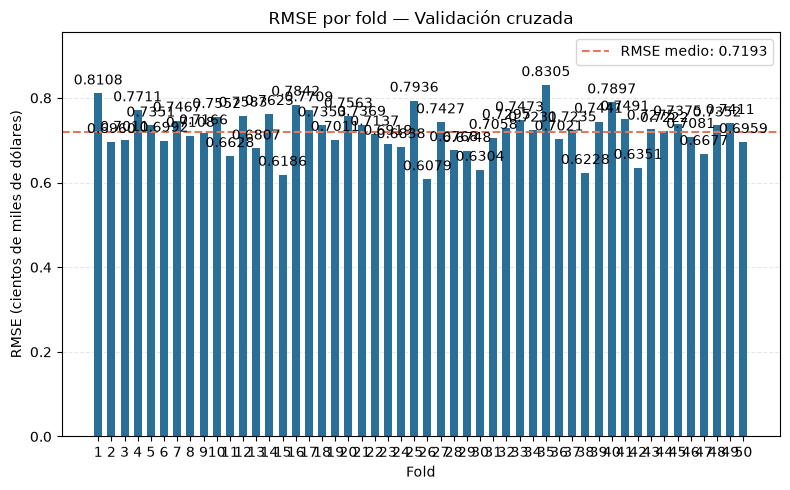

In [24]:
import matplotlib.pyplot as plt

rmse_by_fold = cv_scores["RMSE"]
mean_rmse = rmse_by_fold.mean()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(rmse_by_fold.index, rmse_by_fold, color="#2a6f97", width=0.6)
ax.axhline(mean_rmse, color="#e07a5f", linestyle="--",
           label=f"RMSE medio: {mean_rmse:.4f}")
ax.bar_label(bars, fmt="%.4f", padding=4)
ax.set_title("RMSE por fold — Validación cruzada")
ax.set_xlabel("Fold")
ax.set_ylabel("RMSE (cientos de miles de dólares)")
ax.set_xticks(rmse_by_fold.index)
ax.set_ylim(0, rmse_by_fold.max() * 1.15)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

## Entrenamiento final y evaluación en test

Después de la validación cruzada, ajustamos el pipeline con todo `X_train` e `y_train`. El escalador aprende únicamente del conjunto de entrenamiento. Evaluamos las predicciones sobre el 20 % reservado para prueba, sin ajustar parámetros con sus resultados. RMSE es la métrica principal; MAE y R² complementan la evaluación.

In [25]:
# Ajustar el escalador y la regresión con todo el conjunto train.
model.fit(X_train, y_train)
print(f"Modelo entrenado con {len(y_train):,} observaciones.")

Modelo entrenado con 16,512 observaciones.


In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

# El pipeline aplica a test el escalador ya ajustado en train.
y_pred = model.predict(X_test)

test_metrics = pd.Series({
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
    "MAE": mean_absolute_error(y_test, y_pred),
    "R²": r2_score(y_test, y_pred),
}, name="Test")
display(test_metrics.to_frame().round(4))
print(f"Observaciones de prueba: {len(y_test):,}")
print(f"RMSE en dólares: ${test_metrics['RMSE'] * 100_000:,.0f}")
print(f"MAE en dólares: ${test_metrics['MAE'] * 100_000:,.0f}")

prediction_table = pd.DataFrame({
    "valor_real": y_test,
    "prediccion": y_pred,
    "error_real_menos_prediccion": y_test - y_pred,
})
display(prediction_table.head(10).round(4))

,Test
RMSE,0.7456
MAE,0.5332
R²,0.5758


Observaciones de prueba: 4,128
RMSE en dólares: $74,558
MAE en dólares: $53,320


,valor_real,prediccion,error_real_menos_prediccion
0,0.477,0.7191,-0.2421
1,0.458,1.7640,-1.3060
2,5.000,2.7097,2.2904
3,2.186,2.8389,-0.6529
4,2.780,2.6047,0.1753
5,1.587,2.0118,-0.4248
6,1.982,2.6455,-0.6635
7,1.575,2.1688,-0.5938
8,3.400,2.7407,0.6593
9,4.466,3.9156,0.5504


## Comparación: validación cruzada vs. test

Para RMSE y MAE, un valor menor es mejor; para R², un valor mayor es mejor. La diferencia se calcula como test menos la media de validación cruzada.

In [27]:
# Comparar el promedio y la variabilidad de CV con el test reservado.
comparison = pd.DataFrame({
    "CV media": cv_scores.mean(),
    "CV desviación estándar": cv_scores.std(),
    "Test": test_metrics,
})
comparison["Diferencia (test - CV)"] = comparison["Test"] - comparison["CV media"]
comparison["Cambio relativo (%)"] = (
    comparison["Diferencia (test - CV)"] / comparison["CV media"] * 100
)
display(comparison.round(4))

,CV media,CV desviación estándar,Test,Diferencia (test - CV),Cambio relativo (%)
RMSE,0.7193,0.0485,0.7456,0.0263,3.6588
MAE,0.5291,0.0313,0.5332,0.0041,0.7671
R²,0.6103,0.0400,0.5758,-0.0345,-5.6530


El RMSE aumenta de **0.7205** en CV a **0.7456** en test (**+3.48 %**). El MAE aumenta **0.78 %** y R² baja de **0.6115** a **0.5758**. Test presenta un desempeño algo menor, sobre todo al penalizar errores grandes con RMSE.

La diferencia no demuestra por sí sola sobreajuste: CV entrena con subconjuntos más pequeños y test contiene observaciones distintas. La desviación estándar entre folds describe variabilidad y no es un intervalo de confianza; esta comparación es descriptiva, no una prueba de significancia. No se reajusta el modelo con los resultados de test.